In [21]:
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, f1_score
from sklearn.preprocessing import label_binarize

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

### comparison

In [22]:
# load data
best_all = pd.read_csv("best_all.csv")

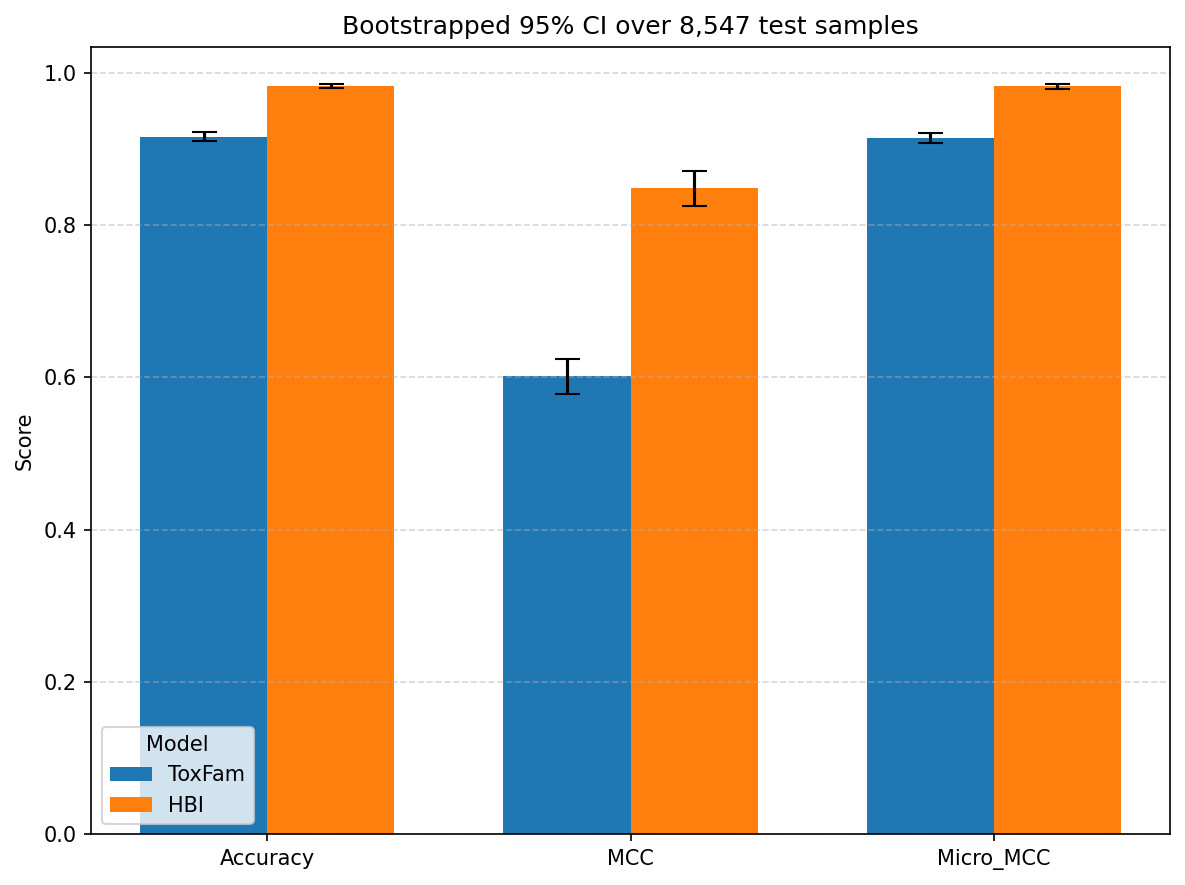

In [23]:
# HBI
hbi = best_all.copy()
hbi["target_label"] = hbi["target_label"].fillna("no hit")
hbi_true = hbi["query_label"].values
hbi_pred = hbi["target_label"].values

# ToxFam
tox = pd.read_csv("../../model/model_output/256_256_05_200ep/test_predictions.csv")
#tox["prediction"]     = tox["prediction"].fillna("no hit")
tox_true = tox["actual_label"].values
tox_pred = tox["predicted_label"].values

# ─────────── 2) Encode labels to integers (shared universe) ───────────
all_classes = sorted(set(hbi_true) | set(hbi_pred) | set(tox_true) | set(tox_pred))
cls2idx = {c:i for i,c in enumerate(all_classes)}

y_true_hbi  = np.array([cls2idx[c] for c in hbi_true])
y_pred_hbi  = np.array([cls2idx[c] for c in hbi_pred])
y_true_tox  = np.array([cls2idx[c] for c in tox_true])
y_pred_tox  = np.array([cls2idx[c] for c in tox_pred])

# ─────────── 3) Bootstrap function ───────────
def bootstrap_metrics(y_true, y_pred, n_bootstrap=1000, ci=0.95, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    accs, mccs, mmccs = [], [], []
    classes = np.arange(len(all_classes))
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, True)
        yt, yp = y_true[idx], y_pred[idx]
        accs.append(accuracy_score(yt, yp))
        mccs.append(matthews_corrcoef(yt, yp))
        # micro‐MCC on flattened one‐hots
        ytb = label_binarize(yt, classes=classes).ravel()
        ypb = label_binarize(yp, classes=classes).ravel()
        mmccs.append(matthews_corrcoef(ytb, ypb))
    def ci_stats(arr):
        lo, hi = np.percentile(arr, [(1-ci)/2*100, (1+ci)/2*100])
        return np.mean(arr), lo, hi
    return {
        "Accuracy":   ci_stats(accs),
        "MCC":        ci_stats(mccs),
        "Micro_MCC":  ci_stats(mmccs),
    }

# ─────────── 4) Run bootstraps ───────────
res_hbi = bootstrap_metrics(y_true_hbi, y_pred_hbi)
res_tox = bootstrap_metrics(y_true_tox, y_pred_tox)

# ─────────── 5) Prepare for plotting ───────────
models  = ["ToxFam", "HBI"]
metrics = ["Accuracy", "MCC", "Micro_MCC"]

# means shape: (n_models, n_metrics)
means = np.array([
    [res_tox[m][0],  res_hbi[m][0]]
    for m in metrics
]).T

# yerr shape: (2, n_models, n_metrics)
low  = np.array([[res_tox[m][0]-res_tox[m][1],  res_hbi[m][0]-res_hbi[m][1]] for m in metrics]).T
high = np.array([[res_tox[m][2]-res_tox[m][0],  res_hbi[m][2]-res_hbi[m][0]] for m in metrics]).T
yerr = np.stack([low, high])

# ─────────── 6) Plot ───────────
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
for i, mdl in enumerate(models):
    ax.bar(
        x + i*width,
        means[i],
        width=width,
        yerr=yerr[:, i],
        capsize=6,
        label=mdl
    )

offset = width*(len(models)-1)/2
ax.set_xticks(x + offset)
ax.set_xticklabels(metrics, ha="center")

ax.set_ylabel("Score")
ax.set_title("Bootstrapped 95% CI over 8,547 test samples")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Model")
plt.tight_layout()
plt.savefig("plots/overall_comparison.png")
plt.show()


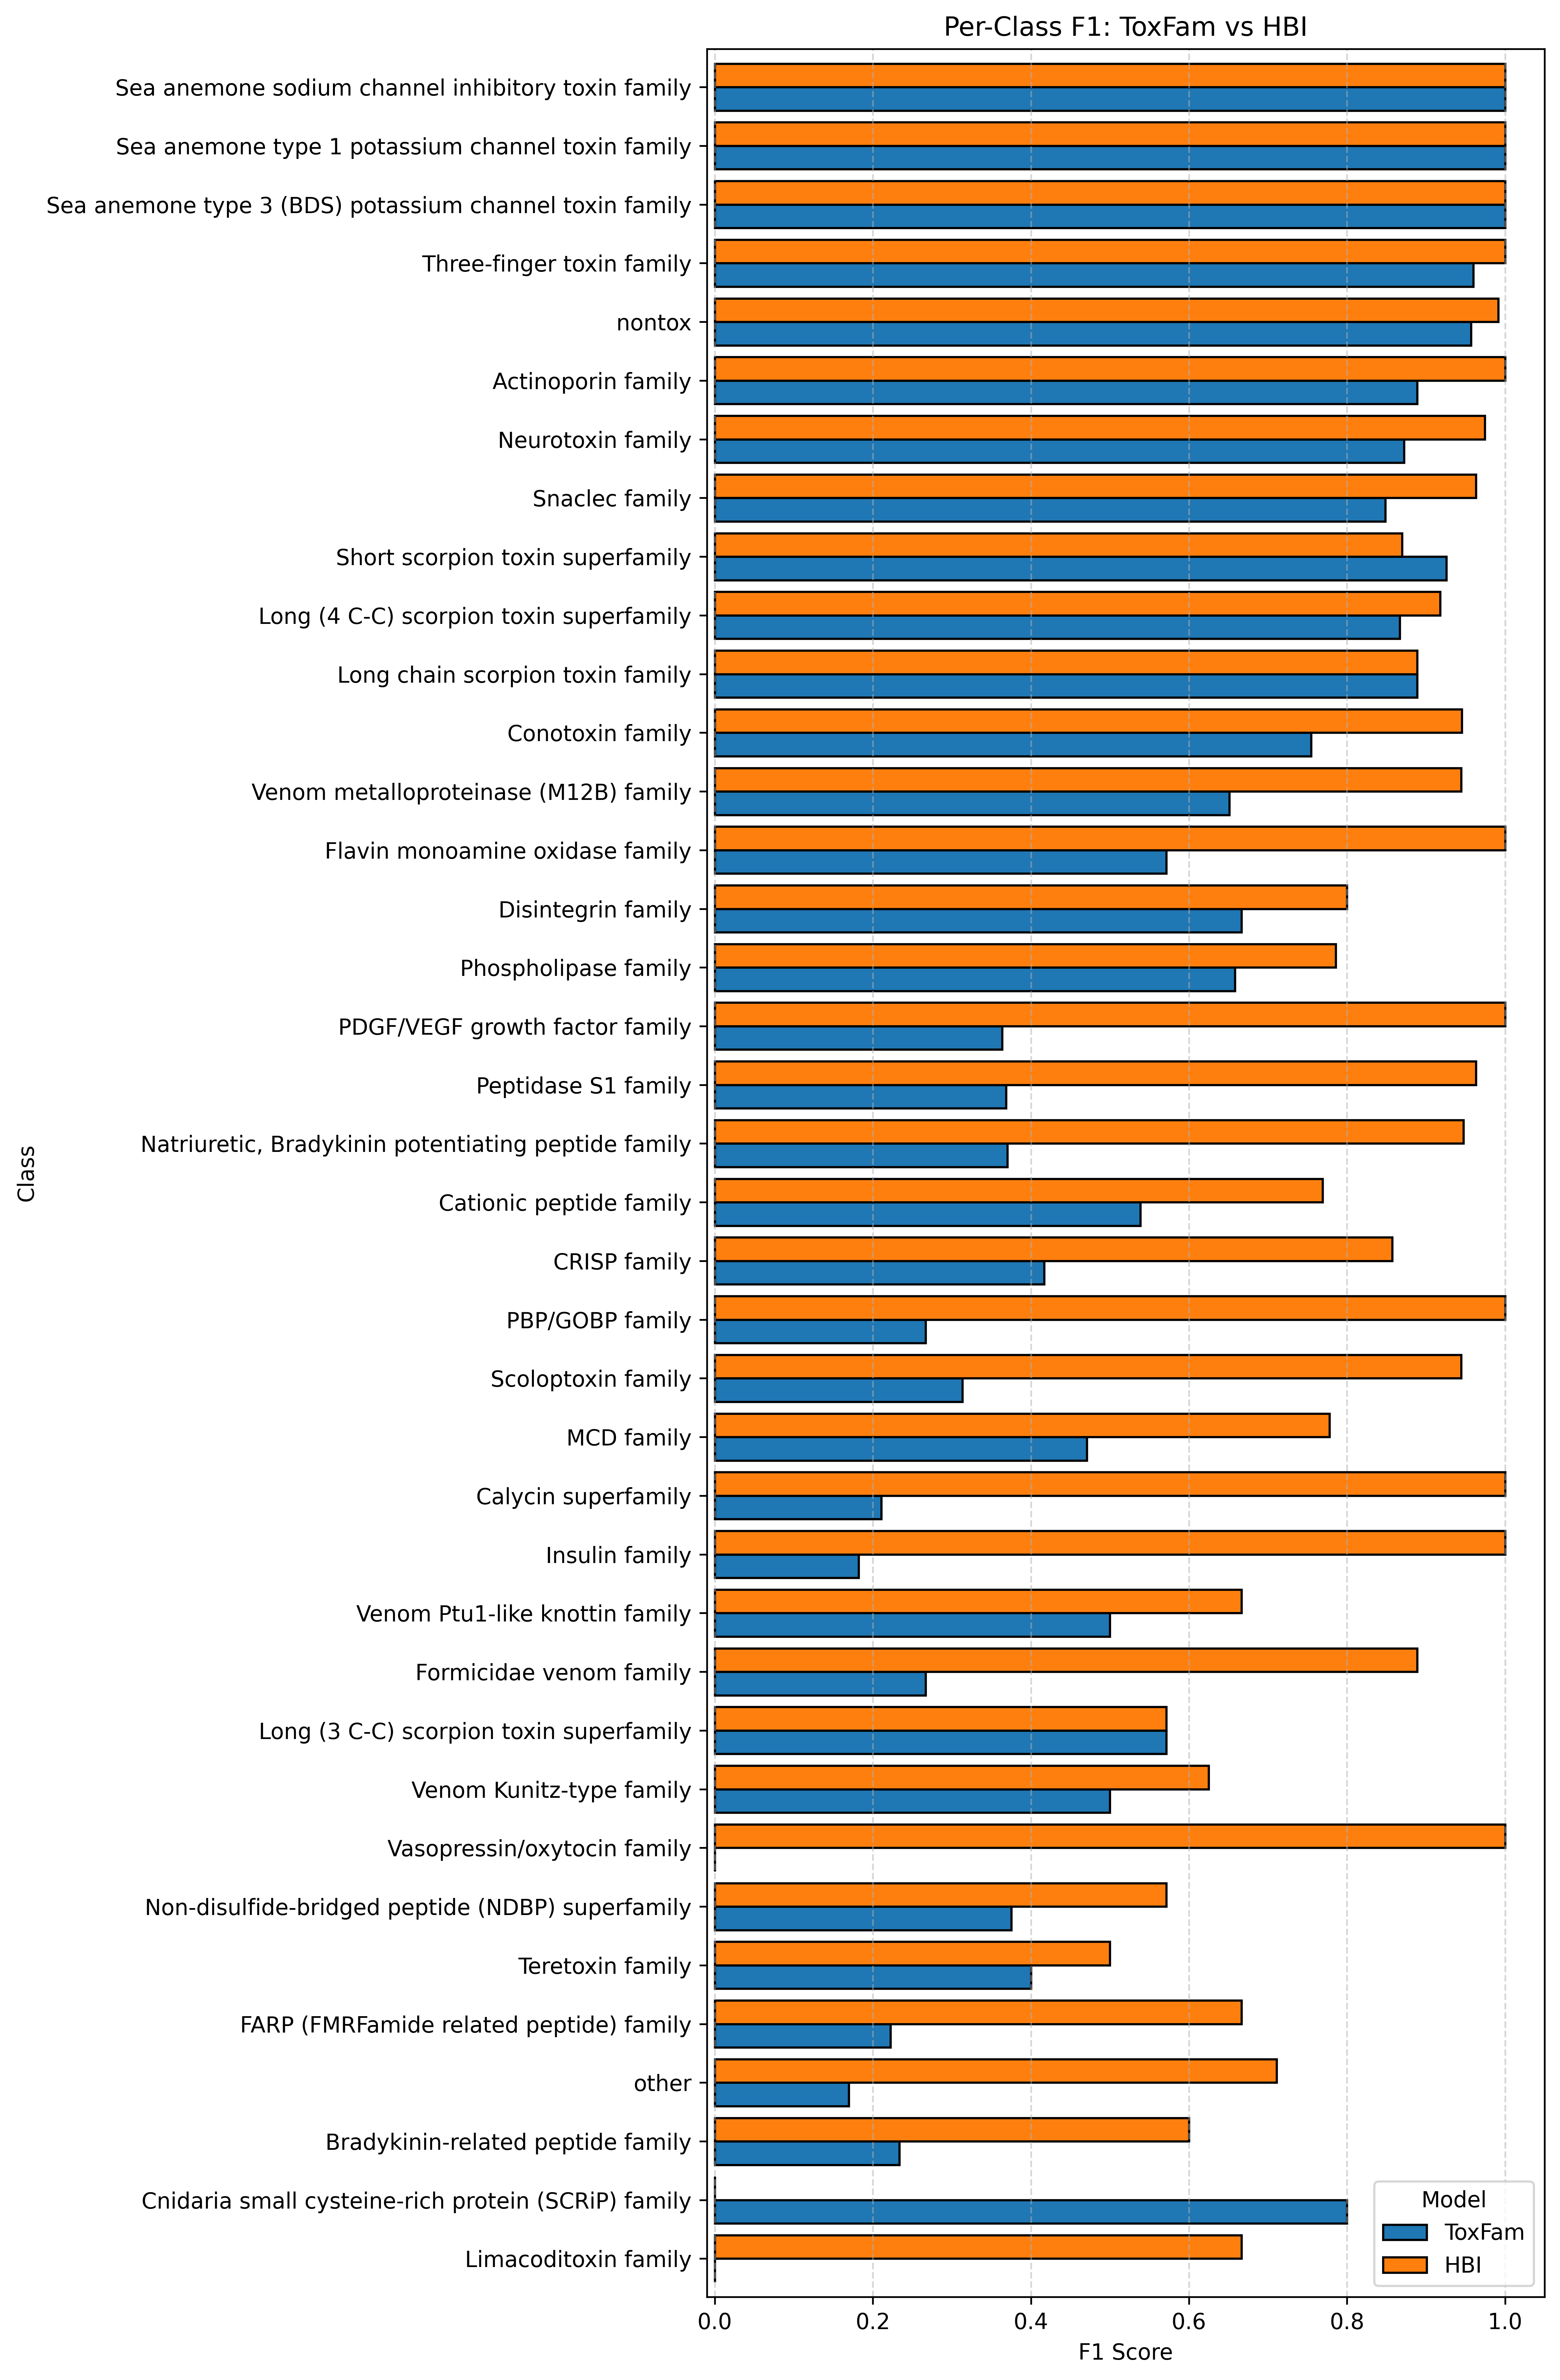

In [24]:
# ——— 1) Load your two sets of predictions ———
hbi = best_all.copy()
hbi["target_label"] = hbi["target_label"].fillna("no hit")
hbi_true = hbi["query_label"].values
hbi_pred = hbi["target_label"].values

#tox = pd.read_csv("../../model/model_output/test_predictions.csv")
#tox_true = tox["actual_label"].values
#tox_pred = tox["prediction"].values

# ——— 2) Compute classification reports ———
cls_report_hbi = classification_report(hbi_true, hbi_pred, output_dict=True, zero_division=0)
cls_report_tox = classification_report(tox_true, tox_pred, output_dict=True, zero_division=0)

# ——— 3) Extract only the per-class entries ———
hbi_per = {k: v for k, v in cls_report_hbi.items() if isinstance(v, dict)}
tox_per = {k: v for k, v in cls_report_tox.items() if isinstance(v, dict)}

# ——— 4) Build the union of all classes, then remove "no hit" ———
all_classes = sorted((set(hbi_per) | set(tox_per)) - {"no hit", "macro avg", "weighted avg"})

# ——— 5) Turn into DataFrames reindexed to that filtered set ———
hbi_df = pd.DataFrame.from_dict(hbi_per, orient="index").reindex(all_classes, fill_value=0)
tox_df = pd.DataFrame.from_dict(tox_per, orient="index").reindex(all_classes, fill_value=0)

# ——— 6) Assemble F1-scores side by side ———
f1_df = pd.DataFrame({
    "ToxFam": tox_df["f1-score"],
    "HBI"   : hbi_df["f1-score"]
}, index=all_classes)

# (Optional) sort by average F1 so lowest-performing classes are on top
f1_df["avg"] = f1_df.mean(axis=1)
f1_df = f1_df.sort_values("avg").drop(columns="avg")

# ——— 7) Plot horizontal grouped bars with custom figure & axes ———
bar_height = 0.4
total_height = max(6, bar_height * len(f1_df))

fig, ax = plt.subplots(figsize=(10, total_height), dpi=480)
f1_df.plot.barh(ax=ax, width=0.8, edgecolor="black", capsize=3)

ax.set_xlabel("F1 Score")
ax.set_ylabel("Class")
ax.set_xlim(-0.01, 1.05)
ax.set_title("Per-Class F1: ToxFam vs HBI")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.legend(title="Model")

plt.tight_layout()
plt.savefig("plots/f1_class_comparison.png")
plt.show()

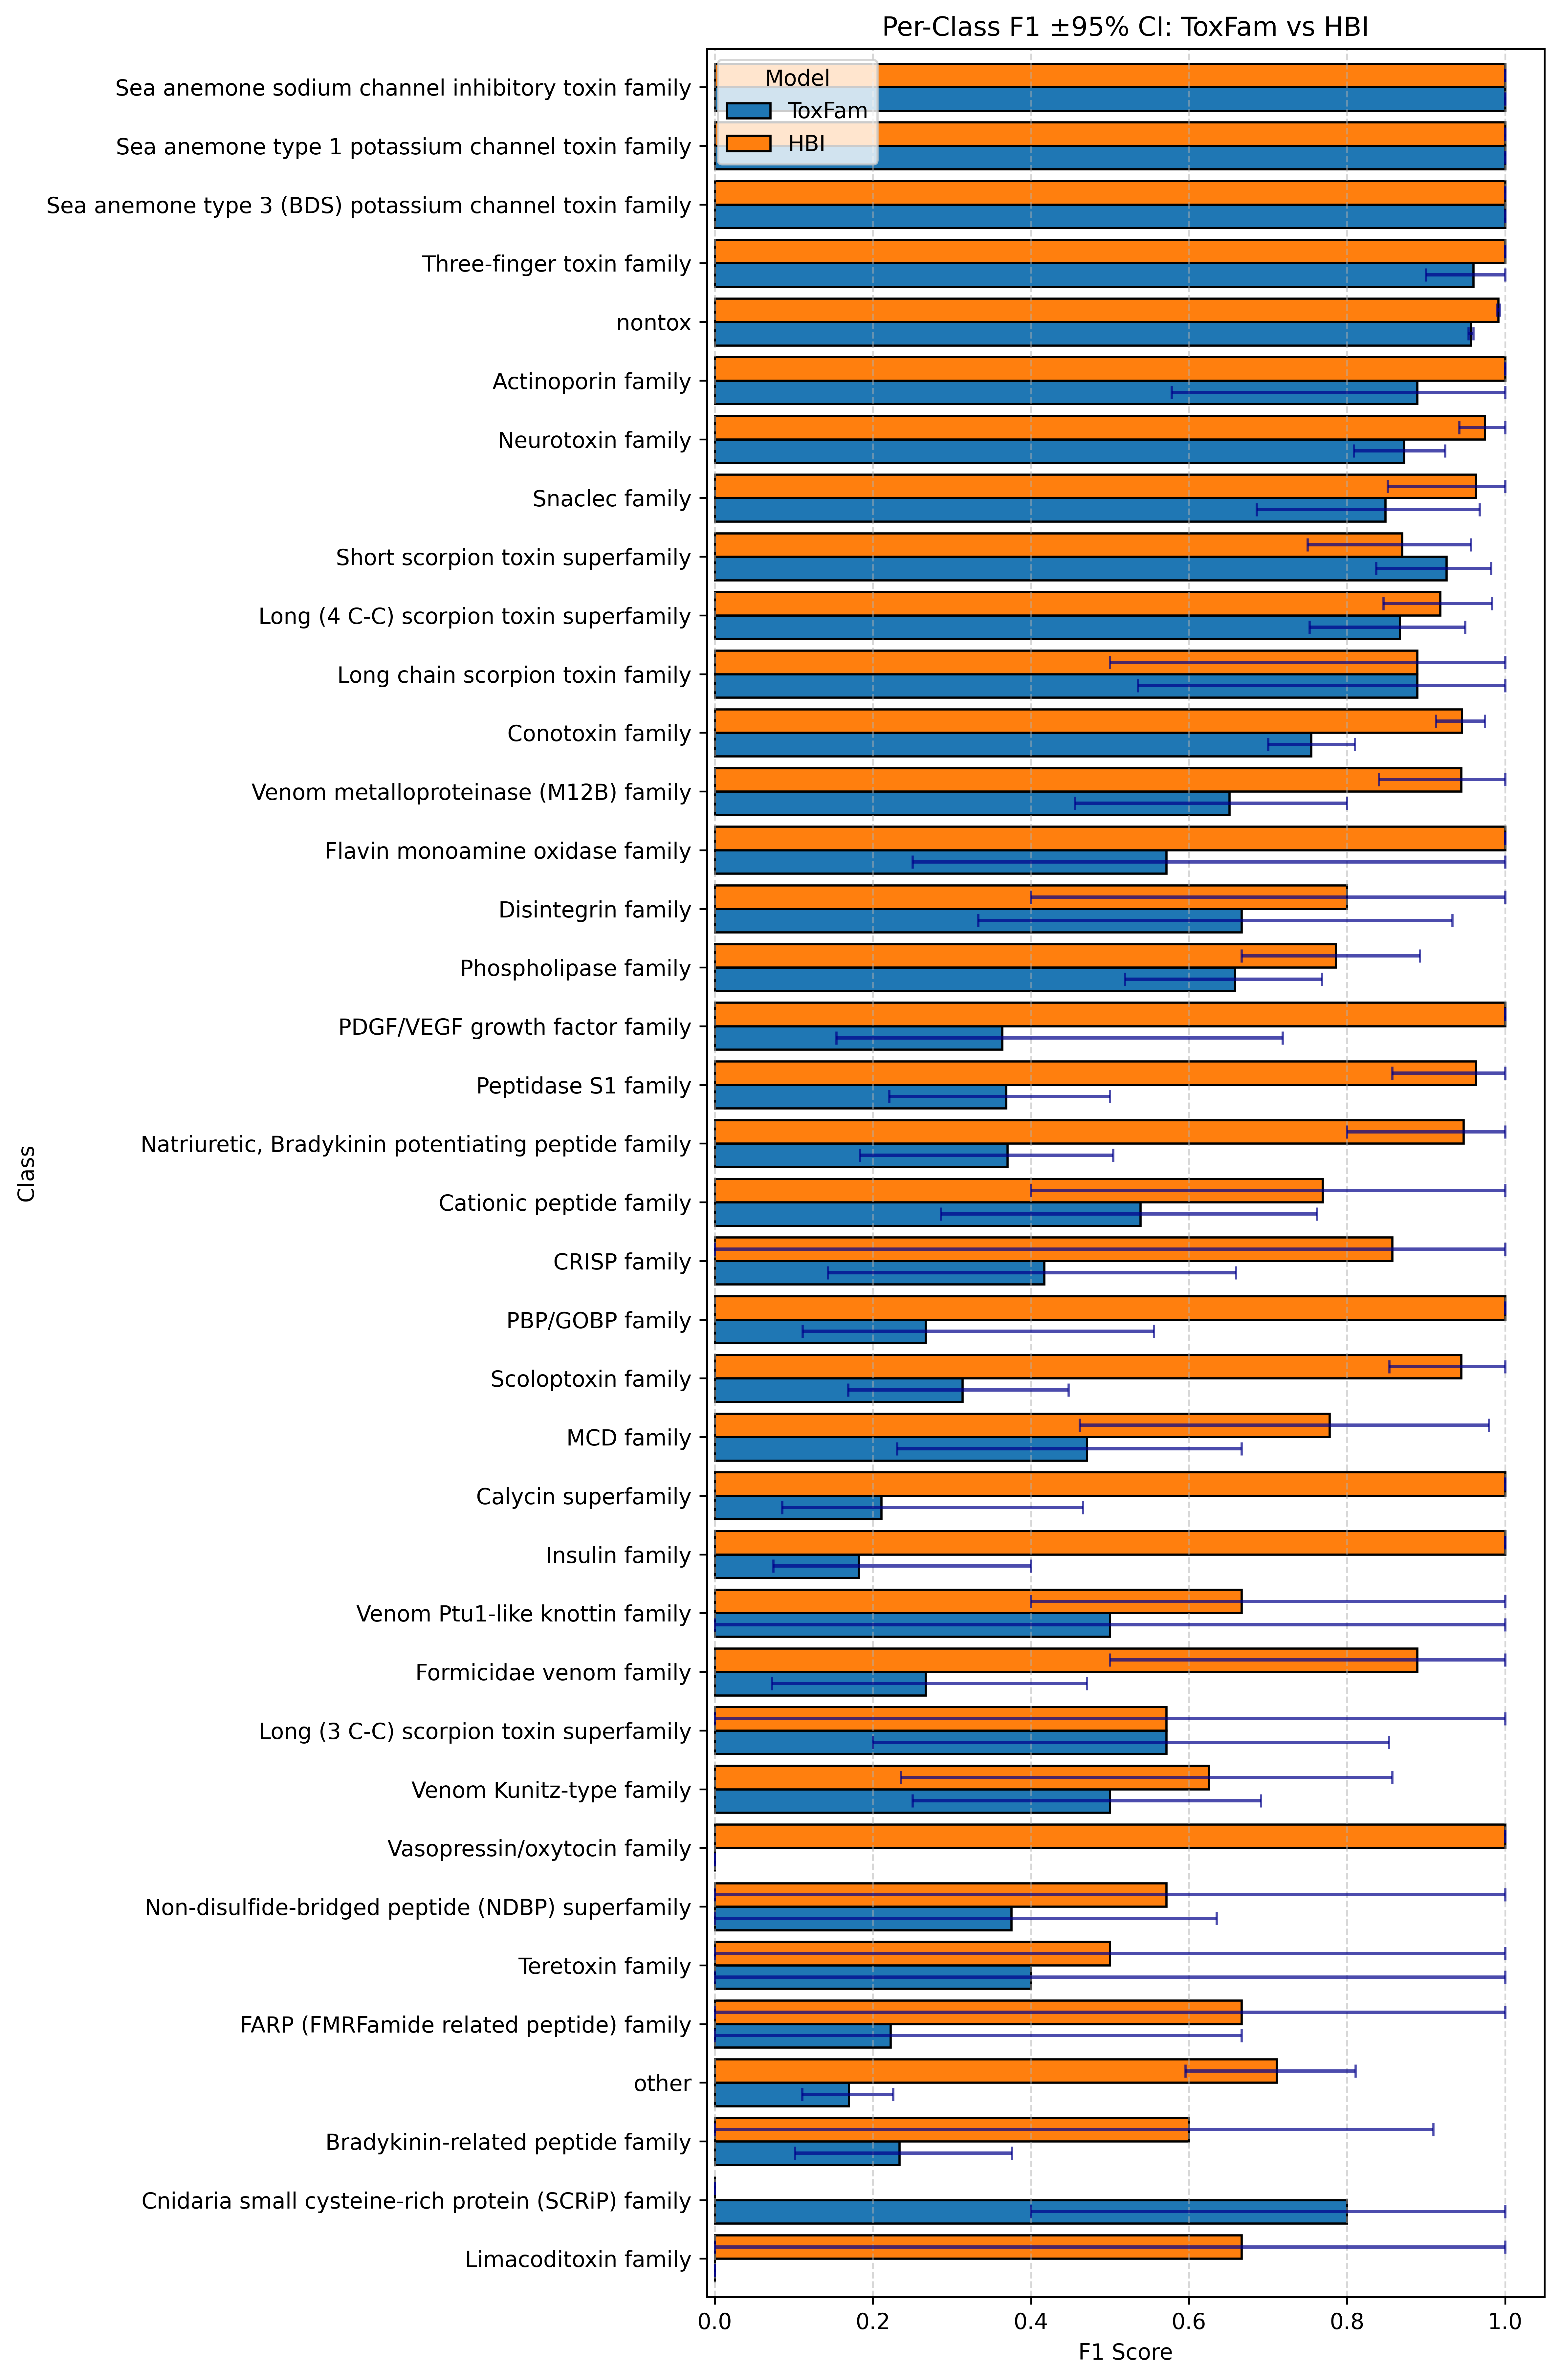

In [25]:
# ——— 1) Load your two sets of predictions ———
hbi = best_all.copy()
hbi["target_label"] = hbi["target_label"].fillna("no hit")
hbi_true = hbi["query_label"].values
hbi_pred = hbi["target_label"].values

# tox = pd.read_csv("../../model/model_output/test_predictions.csv")
# tox_true = tox["actual_label"].values
# tox_pred = tox["prediction"].values

# ——— 2) Compute classification reports ———
cls_report_hbi = classification_report(hbi_true, hbi_pred, output_dict=True, zero_division=0)
cls_report_tox = classification_report(tox_true, tox_pred, output_dict=True, zero_division=0)

# ——— 3) Extract per-class entries ———
hbi_per = {k: v for k, v in cls_report_hbi.items() if isinstance(v, dict)}
tox_per = {k: v for k, v in cls_report_tox.items() if isinstance(v, dict)}

# ——— 4) Union of classes minus unwanted ———
all_classes = sorted(set(hbi_per) | set(tox_per))
all_classes = [c for c in all_classes if c not in {"no hit", "macro avg", "weighted avg"}]

# ——— 5) Build dataframes ———
hbi_df = pd.DataFrame.from_dict(hbi_per, orient="index").reindex(all_classes, fill_value=0)
tox_df = pd.DataFrame.from_dict(tox_per, orient="index").reindex(all_classes, fill_value=0)

# ——— 6) Exact F1 centers & sort ———
f1_df = pd.DataFrame({
    "ToxFam": tox_df["f1-score"],
    "HBI"   : hbi_df["f1-score"]
}, index=all_classes)
f1_df["avg"] = f1_df.mean(axis=1)
f1_df = f1_df.sort_values("avg").drop(columns="avg")

# ——— 7) Bootstrap function ———
def bootstrap_per_class_f1(y_true, y_pred, classes, n_bootstrap=1000, ci=0.95, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot = {c: [] for c in classes}
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, True)
        yt, yp = y_true[idx], y_pred[idx]
        for c in classes:
            class_present = sum(yt == c)
            if class_present:
                boot[c].append(f1_score(yt == c, yp == c))
    lo_pct, hi_pct = (1 - ci)/2 * 100, (1 + ci)/2 * 100
    stats = {}
    for c, vals in boot.items():
        lo, hi = np.percentile(vals, [lo_pct, hi_pct])
        # clamp lo & hi to [0,1]
        lo = max(lo, 0.0)
        hi = min(hi, 1.0)
        stats[c] = (lo, hi)
    return stats

classes    = list(f1_df.index)
hbi_stats  = bootstrap_per_class_f1(hbi_true, hbi_pred, classes, n_bootstrap=500, seed=42)
tox_stats  = bootstrap_per_class_f1(tox_true, tox_pred, classes, n_bootstrap=500, seed=42)

# ——— 8) Build centers + explicit lower/upper errors ———
# exact centers
centers = {
    "ToxFam": f1_df["ToxFam"].values,
    "HBI"   : f1_df["HBI"].values
}

# raw percentiles
tox_lo = np.array([tox_stats[c][0] for c in classes])
tox_hi = np.array([tox_stats[c][1] for c in classes])
hbi_lo = np.array([hbi_stats[c][0] for c in classes])
hbi_hi = np.array([hbi_stats[c][1] for c in classes])

# distances to mean
tox_lower = centers["ToxFam"] - tox_lo
tox_upper = tox_hi - centers["ToxFam"]
hbi_lower = centers["HBI"]    - hbi_lo
hbi_upper = hbi_hi    - centers["HBI"]

# clamp distances so mean - lower ≥0 and mean + upper ≤1
tox_lower = np.minimum(tox_lower, centers["ToxFam"])
tox_upper = np.minimum(tox_upper, 1 - centers["ToxFam"])
hbi_lower = np.minimum(hbi_lower, centers["HBI"])
hbi_upper = np.minimum(hbi_upper, 1 - centers["HBI"])

# ensure non-negative
tox_lower = np.clip(tox_lower, 0, None)
tox_upper = np.clip(tox_upper, 0, None)
hbi_lower = np.clip(hbi_lower, 0, None)
hbi_upper = np.clip(hbi_upper, 0, None)

errors = {
    "ToxFam": (tox_lower, tox_upper),
    "HBI"   : (hbi_lower, hbi_upper)
}

# ——— 9) Prepare error array of shape (n_series, 2, n_points) ———
# Series order must match the columns in f1_df: ["ToxFam", "HBI"]
n = len(classes)
err = np.empty((2, 2, n))
# for series 0 (ToxFam):
err[0, 0, :] = tox_lower   # lower errors
err[0, 1, :] = tox_upper   # upper errors
# for series 1 (HBI):
err[1, 0, :] = hbi_lower
err[1, 1, :] = hbi_upper

# ——— 10) Plot with pandas’ barh exactly as before, just adding xerr=err ———
bar_height = 0.4
total_height = max(6, bar_height * n)

fig, ax = plt.subplots(figsize=(10, total_height), dpi=480)
f1_df.plot.barh(
    ax=ax,
    width=0.8,
    edgecolor="black",
    capsize=3,
    xerr=err,
    error_kw={"alpha": 0.7, "ecolor": "darkblue"}
)

ax.set_xlabel("F1 Score")
ax.set_ylabel("Class")
ax.set_xlim(-0.01, 1.05)
ax.set_title("Per-Class F1 ±95% CI: ToxFam vs HBI")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.legend(title="Model")

plt.tight_layout()
plt.savefig("plots/f1_class_comparison_errors.png")
plt.show()



/var/folders/6k/gr_1_h_97154rq71pm_q3jn40000gn/T/ipykernel_33878/875896272.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('rainbow', len(classes))


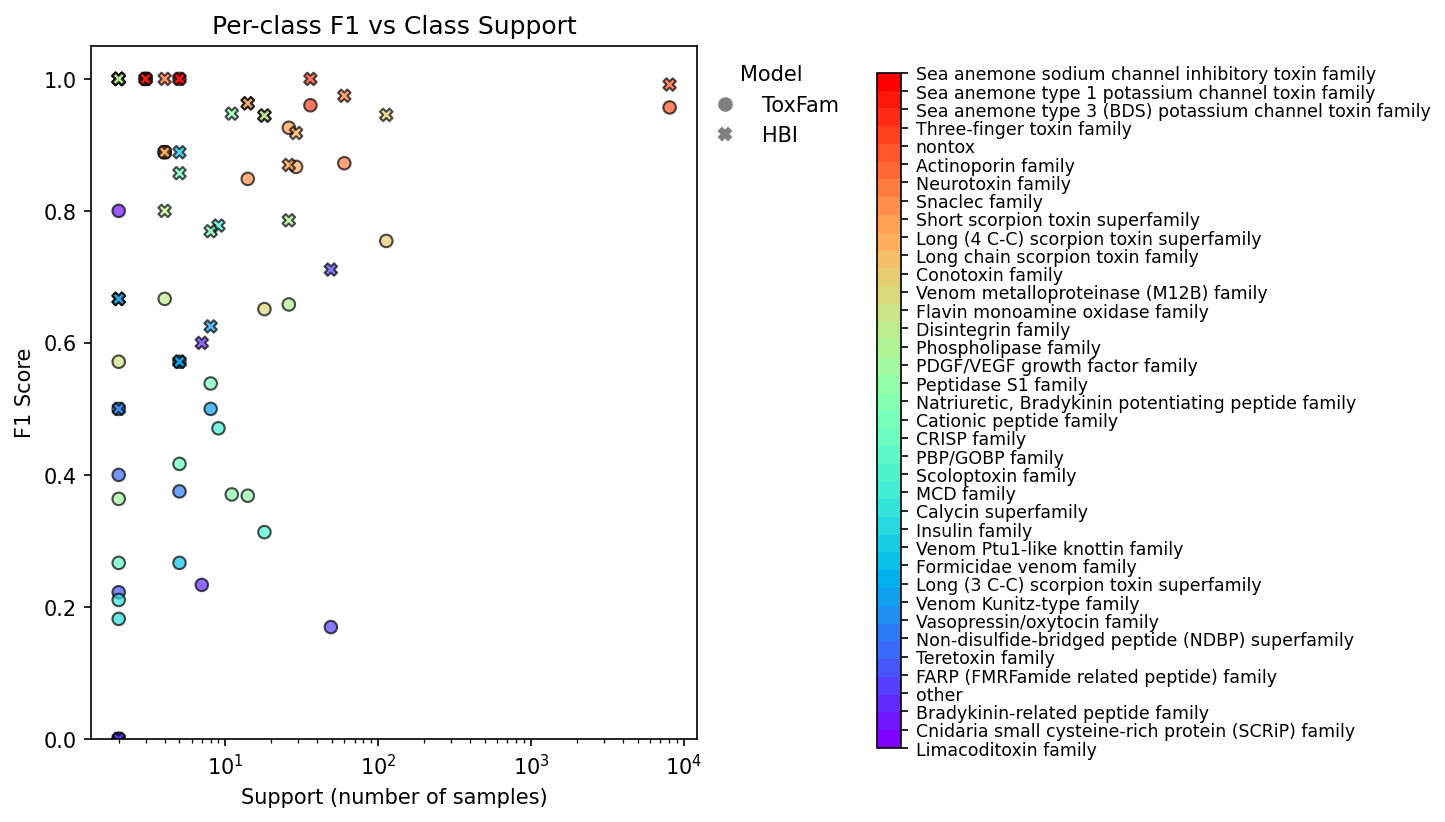

In [26]:
# compute per-class support from the test set (or from the classification report)
support = pd.Series(
    {cls: v["support"] for cls, v in cls_report_tox.items() if isinstance(v, dict)}
)

# or from HBI, depending on which you want to plot support for
# support = pd.Series({cls: v["support"] for cls, v in cls_report_hbi.items() if isinstance(v, dict)})

# reorder so it matches the order of f1_df (your per-class F1 table)
support_sorted = support.reindex(f1_df.index).fillna(0)

classes   = support_sorted.index
supports  = support_sorted.values
class_idx = np.arange(len(classes))

cmap = plt.cm.get_cmap('rainbow', len(classes))
norm = mcolors.Normalize(vmin=0, vmax=len(classes)-1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# leave plenty of room on right
plt.subplots_adjust(right=0.63)

# scatter
sc_tox = ax.scatter(
    supports, f1_df['ToxFam'],
    c=class_idx, cmap=cmap, norm=norm,
    marker='o', edgecolor='black', alpha=0.7
)
sc_hbi = ax.scatter(
    supports, f1_df['HBI'],
    c=class_idx, cmap=cmap, norm=norm,
    marker='X', edgecolor='black', alpha=0.7
)

# axes labels
ax.set_xscale('log')
ax.set_xlabel("Support (number of samples)")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-class F1 vs Class Support")

# Model‐shape legend (moved left)
model_handles = [
    Line2D([], [], marker='o', color='gray', linestyle='', label='ToxFam'),
    Line2D([], [], marker='X', color='gray', linestyle='', label='HBI'),
]
fig.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(0.62, 0.88),  # 62% from left, 85% from bottom
    frameon=False
)

# Colorbar in its own Axes (moved right)
cax = fig.add_axes([0.78, 0.10, 0.02, 0.75])  # left=78%, bottom=10%, width=2%, height=75%
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax
)
cb.set_ticks(class_idx)
cb.set_ticklabels(classes)
cb.ax.tick_params(labelsize='small')
plt.savefig("plots/f1_class_comparison_scatter.png")
plt.show()
